## Only need these if you are running on the commandline

In [2]:
from blueapi.client import BlueapiClient
from blueapi.client.event_bus import AnyEvent
from blueapi.config import (
    ApplicationConfig,
    ConfigLoader,
    HttpUrl,
    RestConfig,
    StompConfig,
    TcpUrl,
)

beamline = "P99"
beamline_config = ApplicationConfig(
        api=RestConfig(
            url=HttpUrl(f"https://{beamline}-blueapi.diamond.ac.uk"),
        ),
        stomp=StompConfig(
            enabled=True,
            url=TcpUrl(f"tcp://{beamline}-rabbitmq-daq.diamond.ac.uk:61613"),
        ))
bc = BlueapiClient.from_config(beamline_config)
bc.login()
bc.instrument_session = "cm44186-1"

# Devices

In [24]:
for device in bc.devices:
    print(device)

Device(sample_stage)
Device(andor2_point)
Device(angle_stage)
Device(panda)
Device(andor2_det)
Device(lab_stage)


# Plans

In [25]:
for plan in bc.plans:
    print(plan)

stxm_fast(dets, count_time, step_motor, step_start, step_end, scan_motor, scan_start, scan_end, plan_time, point_correction=None, step_size=None, home=None, snake_axes=None, md=None)
stxm_step(dets, count_time, x_step_motor, x_step_start, x_step_end, x_step_size, y_step_motor, y_step_start, y_step_end, y_step_size, home=None, snake=None, md=None)
fast_scan_and_move_fit(det, motor, fitted_loc, detname_suffix, start, end, motor_speed=None)
step_scan_and_move_fit(det, motor, fitted_loc, detname_suffix, start, end, num)
align_slit_with_look_up(motor, size, slit_table, det, centre_type)
fast_scan_1d(dets, motor, start, end, motor_speed=None, md=None)
fast_scan_grid(dets, step_motor, step_start, step_end, num_step, scan_motor, scan_start, scan_end, motor_speed=None, snake_axes=None, md=None)
grid_fast_scan(dets, count_time, step_motor, step_start, step_end, scan_motor, scan_start, scan_end, plan_time, point_correction=None, step_size=None, home=None, snake_axes=None, md=None)
grid_step_scan(

# Run the area plans with andor2 as point detector.

In [29]:
bc.plans.stxm_step(dets = [bc.devices.andor2_point],
                   count_time = 0.2,
                   x_step_motor= bc.devices.sample_stage.x,
                   x_step_start = -3, 
                   x_step_end = 3,
                   x_step_size = 0.25,
                   y_step_motor = bc.devices.sample_stage.y,
                   y_step_start = -3,
                   y_step_end = 3,
                   y_step_size = 0.25)

## Run the area plans with andor2.

In [32]:
bc.plans.stxm_step(dets = [bc.devices.andor2_det],
                   count_time = 0.2,
                   x_step_motor= bc.devices.sample_stage.x,
                   x_step_start = -2.5, 
                   x_step_end = -1.5,
                   x_step_size = 0.1,
                   y_step_motor = bc.devices.sample_stage.y,
                   y_step_start = -2,
                   y_step_end = 1,
                   y_step_size = 0.1)

# Trigger workflow on p99.diamond Plot the data

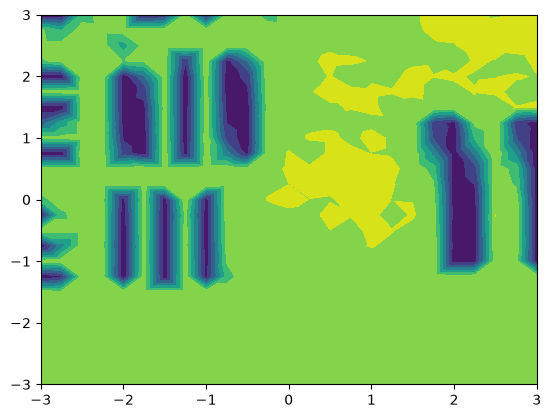

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
nexusData = h5py.File(f"/dls/p99/data/2026/cm44186-1/p99-bs-84.nxs",  "r")
data =nexusData["entry/instrument"]
plt.tricontourf(data["sample_stage-x/sample_stage-x"],data["sample_stage-y/sample_stage-y"],data["andor2_point/mean"])

In [27]:
c = 30
with h5py.File(f"/dls/p99/data/2026/cm44186-1/processing/workflows/ptypy/scan_85/85_DM_0100.ptyr",  "r") as f:
    data = np.array(f["content/obj/Sscan_00G00/data"][0,c:-c,c:-c])
    amp = np.abs(data)
    phase = np.angle(data)


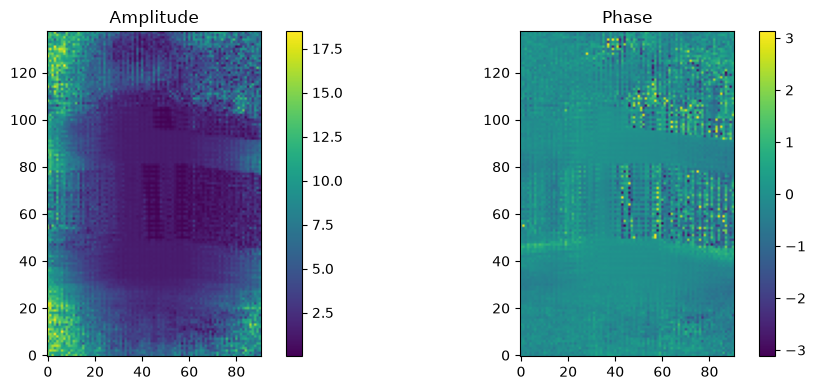

In [31]:
# Plot both 2D grids side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(amp, cmap='viridis', origin='lower')
axes[0].set_title('Amplitude')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(phase, cmap='viridis', origin='lower')
axes[1].set_title('Phase')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()